# Language Modeling with Embeddings — an MLP

> ↩ **Previous in the series:** [Building a Neural Network from Scratch](neural_net.ipynb)


Our first language model: predict the next character with a plain multi-layer perceptron. PyTorch tensors, but every parameter created and updated by hand.

This notebook is the bridge between the [neural network notebook](neural_net.ipynb) and the [transformer notebook](transformer.ipynb). There we built an autograd engine around a single number (`Value`) and trained an MLP to separate two rings of points. The transformer notebook — the next step in the series — jumps to PyTorch modules and attention. Two things happen in that jump that deserve their own notebook:

1. **Scalars become tensors.** The `Value` class wrapped one number; PyTorch wraps whole arrays. Same autograd, new container — and we'll verify that claim on the exact example from the neural-net notebook.
2. **Characters become vectors.** A network does arithmetic, so text must become numbers first. The tool for that is the **embedding** — a learned lookup table that turns each character into a small vector. It's the single most load-bearing idea this notebook adds, and it's the same mechanism (scaled up) behind word2vec and the first layer of every GPT.

### The task we're going to solve

**Given the previous 8 characters of Shakespeare, predict the character that comes next.** Same corpus, same character vocabulary, and the same job the next notebook takes on with attention — on purpose, so the losses stay directly comparable across the series. Two reference points to hold onto: the simplest possible language model (a **bigram**, which predicts from only the single current character) manages a loss of ~2.5 on this data, and the full GPT built in the next notebook reaches ~1.7. This notebook's MLP will land in between — and *where* it gets stuck is the whole reason attention exists.

The architecture comes from Bengio et al.'s 2003 paper *A Neural Probabilistic Language Model* — the design that introduced learned embeddings for language — by way of Andrej Karpathy's [makemore](https://github.com/karpathy/makemore) series.

### The training loop hasn't changed

The four-step loop from the neural-net notebook — **predict, score, assign blame, nudge** — is still the entire story. Only two ingredients are swapped: the model in the middle (an MLP over embeddings instead of over raw coordinates) and the loss (cross-entropy instead of hinge, because now we're choosing among 65 classes instead of 2).

| Step | What we build | Why we need it |
|------|--------------|----------------|
| 1 | Scalars → tensors | Verify PyTorch's autograd is our `Value` class, batched |
| 2 | Data: text → training examples | 8 characters of context → 1 correct next character |
| 3 | One-hot vectors | The obvious way to feed IDs to a network — and why it's a dead end |
| 4 | Embeddings | The lookup table that replaces one-hot; the idea that scales |
| 5 | The MLP | Concatenate 8 embeddings, push through a hidden layer, score 65 characters |
| 6 | Softmax + cross-entropy | Turn 65 raw scores into a trainable "how wrong were we?" number |
| 7 | Training | The four-step loop, now with manual tensor updates |
| 8 | Sampling + what the embeddings learned | Generate text; look at the geometry the table discovered |
| 9 | The wall | Why this architecture can't scale its context — the door to attention |


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1337)  # reproducible weights + batches (1337 is Karpathy's traditional seed)


## Step 1: Scalars → tensors

The neural-net notebook's `Value` class wrapped **one number** and recorded every `+` and `*` so that `backward()` could fill in every `.grad`. PyTorch's [tensor](https://docs.pytorch.org/docs/tensors.html) is the same machine wrapping an **array** of numbers. Same graph recording, same chain rule, same `.backward()`, same `.grad` — just applied to whole blocks of numbers at once.

**Why bother with arrays?** One matrix multiply computes what would otherwise be thousands of scalar `+` and `*` operations. Recall the ring classifier: a `Layer` of 16 neurons looped over each neuron, and each neuron looped over its weights — hundreds of Python-level `Value` operations per data point. A tensor library replaces those nested loops with a single `X @ W`: the whole layer, for the whole batch, in one call that runs in optimized C (and on a GPU, in parallel hardware). The math is identical; the bookkeeping moves out of Python.

**The claim to verify:** in the neural-net notebook we hand-computed `d = (a + b) * b` with `a = 2, b = 3`, and backprop gave `a.grad = 3` and `b.grad = 8` (the 8 because `b` feeds two operations, so its gradients from both paths add up). If PyTorch is really the same engine, it must produce exactly those numbers — the cell below checks.

> **`requires_grad=True`.** Our `Value` class recorded *every* operation. PyTorch only records operations that touch a tensor you've flagged with `requires_grad=True` — that flag marks "this is a parameter (or depends on one); I'll want its gradient." Data tensors stay unflagged, so no graph is built for them. This is the tensor-world version of the neural-net notebook's split between parameters (nudged) and data (not).


In [3]:
# The exact example from the neural-net notebook: d = (a + b) * b, a = 2, b = 3.
# Our hand-written Value class produced a.grad = 3.0 and b.grad = 8.0.
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = a + b            # recorded in the graph, exactly like Value.__add__
d = c * b            # recorded, exactly like Value.__mul__
d.backward()         # one reverse sweep — the same topological walk our backward() did

print(f'a.grad = {a.grad}')   # 3.0 — matches the Value class
print(f'b.grad = {b.grad}')   # 8.0 — b feeds two ops, gradients accumulate, same as before

# Now the payoff: the SAME engine on arrays. One matmul = a whole layer's worth of neurons.
W = torch.randn(3, 2, requires_grad=True)   # like 2 neurons with 3 weights each, as one array
x = torch.randn(4, 3)                        # a batch of 4 inputs, 3 features each (data: no flag)
out = (x @ W).sum()                          # every multiply-add of every neuron, one call
out.backward()                               # fills W.grad — all 6 weight gradients in one sweep

print(f'\nW.grad shape = {tuple(W.grad.shape)}  (one gradient per weight, computed together)')


a.grad = 3.0
b.grad = 8.0

W.grad shape = (3, 2)  (one gradient per weight, computed together)


## Step 2: Data — text → training examples

We load the same [tiny Shakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt) corpus — ~1.1 MB of Shakespeare plays, the training text for this notebook and the next. The tokenizer is the simplest one possible: each of the 65 distinct characters gets an integer ID. A **token** here is one character; the [tokenizer notebook](tokenizer.ipynb), later in the series, is about what replaces this simplistic scheme in real models.

**Manufacturing examples.** The model's job is "8 characters in → 1 character out," so a training example is a window: take any 8 consecutive characters as the **context** `x`, and the character right after them as the **target** `y`. Slide the window one step and you get the next example. A 1-million-character text yields roughly a million examples, no hand-labeling required — the text supervises itself.

```
"First Cit" →  context: "First Ci"   target: "t"
 "irst Citi" →  context: "irst Cit"   target: "i"
```

We split 90/10 into training and validation text *before* windowing, for the same reason as always: loss on windows the model never trained on is the honest measure. (One prediction per window, made only after the full context — the MLP has no mechanism for predicting at *every* position along the way. Remember that limitation; Step 9 comes back to it.)

> **Naming trap, same as ever: `X` and `Y`.** Capital `X` = inputs (integer IDs of the 8 context characters), `Y` = the correct answers (the ID of the 9th). Nothing geometric about them.


In [5]:
text = open('input.txt', 'r').read()
print(f'{len(text)} characters')

chars = sorted(set(text))
vocab_size = len(chars)
print(f'Vocab size: {vocab_size}')

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

block_size = 8   # context length: predict character 9 from characters 1..8

def build_dataset(t):
    data = torch.tensor(encode(t), dtype=torch.long)
    # Every position i yields one example: context data[i : i+8] -> target data[i+8].
    # unfold() creates all the sliding windows at once; .contiguous() materializes them as real rows.
    X = data[:-1].unfold(0, block_size, 1).contiguous()   # (N, 8) — all length-8 windows
    Y = data[block_size:]                     # (N,)   — the character after each window
    return X, Y

n = int(0.9 * len(text))                     # split the TEXT first, then window each part
Xtr, Ytr = build_dataset(text[:n])
Xva, Yva = build_dataset(text[n:])
print(f'Train: {len(Xtr)} examples, Val: {len(Xva)} examples')

# Look at three consecutive examples — the window sliding one character at a time.
for i in range(3):
    print(f'  context: {decode(Xtr[i].tolist())!r}  ->  target: {itos[Ytr[i].item()]!r}')


1115394 characters
Vocab size: 65
Train: 1003846 examples, Val: 111532 examples
  context: 'First Ci'  ->  target: 't'
  context: 'irst Cit'  ->  target: 'i'
  context: 'rst Citi'  ->  target: 'z'


## Step 3: One-hot — the obvious encoding, and why it's a dead end

The context is now 8 integer IDs, but feeding raw IDs into a network is wrong in a subtle way: the network would do arithmetic on them, and the arithmetic is meaningless. Character ID 43 is not "43 times more" of anything than ID 1 — the numbering is an arbitrary alphabetical accident. Multiply an ID by a weight and you've baked that accident into the math.

The classic fix is **one-hot encoding**: represent character `i` as a 65-dimensional vector of zeros with a single 1 at position `i`. Now no character is "bigger" than another; each occupies its own axis.

It works, but look at what it costs:

- **Size.** Each character becomes 65 numbers, 64 of them zero. Our 8-character context becomes `8 × 65 = 520` mostly-empty inputs. With a real 50k-token vocabulary that's 400,000 inputs — for 8 tokens of context.
- **No similarity.** Every pair of one-hot vectors is exactly the same distance apart. `e` is as different from `a` as it is from `;`. The network gets zero help generalizing: everything it learns about contexts containing `e` says *nothing* about contexts containing the nearly-interchangeable `a`. Each character's statistics must be learned from scratch.

**The observation that saves us:** watch what happens when a one-hot vector meets a weight matrix. `one_hot(i) @ W` multiplies a vector that is all zeros except position `i` against every column of `W` — every term dies except the ones touching row `i`. The result is exactly **row `i` of `W`**. The matrix multiply is a very expensive way to *select a row*. So skip the ceremony: keep a matrix, and just index into it. That matrix is the embedding table, next.


In [9]:
# One-hot in code, and the row-selection identity that motivates embeddings.
ids = torch.tensor(encode("hello"))
onehot = F.one_hot(ids, num_classes=vocab_size).float()
print(f'"hello" as IDs:     {ids.tolist()}')
print(f'one-hot shape:      {tuple(onehot.shape)}   (5 characters x 65 dims, 1 one per row)')
print(f'nonzeros per row:   {onehot.sum(dim=1).tolist()}')

# The identity: one_hot(i) @ W  ==  W[i]  (a matmul that just selects a row)
W = torch.randn(vocab_size, 10)   # stand-in weight matrix: one 10-number row per character (values don't matter, shape does)
# Each output row is a weighted sum of ALL 65 rows of W — but the one-hot weights zero out
# 64 of the 65 terms, leaving 1 * W[id]. 650 multiplications per character, just to copy one row.
via_matmul = onehot @ W      # (5, 65) @ (65, 10) -> (5, 10), the slow ceremonial way
# Indexing with the integer IDs grabs the same 5 rows directly — no multiplications at all.
via_lookup = W[ids]          # direct row indexing, the same result for free
# allclose = float-safe equality check (the matmul went through real float arithmetic, so no exact ==)
print(f'\none_hot @ W equals W[ids]: {torch.allclose(via_matmul, via_lookup)}')


"hello" as IDs:     [46, 43, 50, 50, 53]
one-hot shape:      (5, 65)   (5 characters x 65 dims, 1 one per row)
nonzeros per row:   [1.0, 1.0, 1.0, 1.0, 1.0]

one_hot @ W equals W[ids]: True


## Step 4: Embeddings — the lookup table

An **embedding table** is a matrix `C` with one row per vocabulary item: shape `(65, n_embd)`. To represent character `i`, take row `i` — that row is the character's vector. We choose `n_embd = 10`, so each character is 10 numbers instead of a 65-dimensional one-hot. The rows start random and are **learned**: `C` is a parameter like any weight, and backprop updates it. (By the Step 3 identity, this is *exactly* one-hot-times-matrix with the wasteful multiply skipped — so nothing conceptually new is being smuggled in, we're just doing the same linear layer efficiently.)

**Why learned vectors beat one-hot.** In a 10-dimensional space, characters can be *near or far from each other* — one-hot's everyone-equidistant property is gone, and that's the point. Nobody tells the model that vowels behave alike. But `a` and `e` keep appearing in interchangeable contexts (`h_t`, `b_st`, `th_n`), and the loss pushes their rows toward each other, because if they're nearby, everything learned about contexts with `e` transfers to contexts with `a` for free. **Similarity in meaning becomes similarity in geometry** — discovered, not programmed. We'll plot the table after training and see it.

This one idea, scaled up, goes a long way:

| Where | The table | Rows mean |
|-------|----------|-----------|
| This notebook | `(65, 10)` | characters |
| word2vec (2013) | `(1M, 300)` | words — famously `king − man + woman ≈ queen` |
| The next notebook (transformer) | `(65, 32)` | characters, feeding attention |
| GPT-scale models | `(100k+, 10k+)` | word-pieces |

**Indexing with a whole batch.** PyTorch indexing is generous: `C[Xb]`, where `Xb` is a `(B, 8)` batch of ID windows, looks up every ID at once and returns shape `(B, 8, 10)` — for each of the `B` examples, 8 characters, each now a 10-vector. One gotcha to know about gradients: only the rows that were actually looked up in a batch receive gradient updates that step. Rare characters' rows train rarely — which is fine here, but becomes a real consideration at 100k-token vocabularies.

> **The `(B, T, C)` shapes.** Deep-learning code names these three axes with standard letters: `B` = batch, `T` = time (position within the window), `C` = channels (the per-position vector length). Our `(B, 8, 10)` is exactly `(B, T, C)` with `T = 8, C = 10`. The rest of the series leans on this convention, so it's worth internalizing here.


In [11]:
n_embd = 10   # each character becomes a 10-number vector

g = torch.Generator().manual_seed(1337)          # one seeded generator for all parameter init
C = torch.randn((vocab_size, n_embd), generator=g)

# Look up an entire batch of contexts in one indexing operation.
Xb = Xtr[:4]                      # (4, 8) — four contexts of 8 character IDs
emb = C[Xb]                        # (4, 8, 10) — every ID replaced by its 10-vector
print(f'Xb shape:  {tuple(Xb.shape)}   (B=4 contexts, T=8 IDs each)')
print(f'C[Xb] shape: {tuple(emb.shape)}   (each ID -> its row of C: B, T, C = 4, 8, 10)')

# Same character, same vector — 'e' gets identical rows wherever it appears.
i, j = encode('e')[0], encode('a')[0]
print(f'\nC[e] == C[e] everywhere it is looked up: {torch.equal(C[i], C[i])}')
print(f'distance e<->a before training: {(C[i] - C[j]).norm():.3f}  (random for now — Step 8 revisits)')


Xb shape:  (4, 8)   (B=4 contexts, T=8 IDs each)
C[Xb] shape: (4, 8, 10)   (each ID -> its row of C: B, T, C = 4, 8, 10)

C[e] == C[e] everywhere it is looked up: True
distance e<->a before training: 6.318  (random for now — Step 8 revisits)


## Step 5: The MLP

Now the model. It is architecturally the *same MLP as the ring classifier* — linear layer, nonlinearity, linear layer — with an embedding lookup bolted on the front and 65 outputs instead of 1:

```
(B, 8) IDs ──C[X]──► (B, 8, 10) ──flatten──► (B, 80) ──W1,b1──► tanh ──► (B, 200) ──W2,b2──► (B, 65) logits
   context      lookup       8 vectors     concatenate    hidden layer              output layer     scores
```

The model is four stages, and each does exactly one job. The trouble with reading a diagram like this is that the *purpose* of each arrow gets lost in the shapes, so below each stage leads with the job it does, then how it does it. We trace one example the whole way through using **toy sizes — 2 numbers per character and a 3-character context** instead of the real 10 and 8 — so the arithmetic stays small enough to see. The real shapes are in parentheses.

**Stage 1 — Lookup. Job: turn symbols into vectors the network can do math on.**
A character ID is just a label. The vocabulary assigns `'e'`, `'t'`, `'h'` each some number, but that number is meaningless as a quantity — a bigger ID isn't "more" of anything, and you can't sensibly multiply a weight by "the character `'t'`." The network only knows how to add and multiply, so each ID is first replaced by its learned row of `C` (the table from Step 4).

Take the context `t h e`, with IDs say `20, 8, 5`. The lookup pulls three rows of `C`:

```
C[20] = [ 0.9, -0.3]     <- 't'
C[ 8] = [ 0.1,  0.7]     <- 'h'
C[ 5] = [-0.5,  0.2]     <- 'e'
```

`C[Xb]` does this for all positions (and the whole batch) at once, giving shape `(B, 3, 2)` in the toy — `(B, 8, 10)` for real.

**Stage 2 — Concatenate. Job: pack the context into the one fixed-length vector a dense layer requires.**
The lookup leaves us with *three separate* vectors, but the next layer is a single matrix multiply, and that takes *one* vector of a known, fixed length. `.view(-1, 6)` lays the three end to end:

```
[ 0.9, -0.3,   0.1, 0.7,   -0.5, 0.2 ]
  '-- t --'   '-- h --'   '-- e --'
```

one 6-number vector (real: 80). **Nothing is merged or discarded** — every character's vector is still fully present, and order is preserved, because `'t'` always lands in slots 1–2, `'h'` in 3–4, `'e'` in 5–6. That fixed slotting is exactly what lets a single layer read the entire context in one shot. (Averaging the three vectors would also produce a fixed size, but it would blur *which* character sat *where* — fatal when order is the whole signal.) The one price of the fixed slotting — that each position gets its own private weights — is what Step 9 returns to; here it is simply the plumbing that makes the next stage possible.

**Stage 3 — Hidden layer. Job: find useful combinations across the whole context.**
`tanh(embcat @ W1 + b1)`. Each of the 200 hidden neurons (real) owns one weight for every input, so it computes a weighted sum over the *entire* concatenated context and then squashes the result. One neuron, toy-sized:

```
h1 = tanh( w1*0.9 + w2*(-0.3) + w3*0.1 + w4*0.7 + w5*(-0.5) + w6*0.2 + b )
```

The `tanh` is what makes such combinations possible at all: without a nonlinearity the two linear layers would collapse into a single linear one, and the model could only draw straight-line boundaries (the same argument as the ring classifier's ReLU). `tanh` squashes to (−1, 1); it saturates for large inputs, which is why `W1` is scaled down at init — see the note below.

**Stage 4 — Output layer. Job: score every possible next character.**
`h @ W2 + b2` projects the hidden vector down to one number per vocabulary item. Continuing the toy — a 4-number hidden vector and a 5-character vocabulary (real: 200 and 65):

```
h      = [ 0.8, -0.2, 0.5, -0.9 ]          the 4 hidden features (real: 200)
           @ W2 (4x5) + b2 (5)             each column of W2 scores one candidate character
logits = [ 1.2, -0.4, 0.3, 2.1, -1.0 ]     one raw score per possible next character (real: 65)
```

Each logit is the dot product of `h` with one column of `W2` — column *j* is "the feature pattern character *j* wants to see," so a high score means the context's features line up with that character. These raw scores are called **logits** — a name that sticks for the rest of the series. They are not probabilities yet (they can be negative and don't sum to 1); Step 6's softmax is what turns the vector into a distribution.

**No `nn.Module`, on purpose.** PyTorch ships ready-made layer classes (`nn.Linear`, `nn.Embedding`) and the next notebook will use them; here every parameter is a bare tensor we create, flag with `requires_grad`, and update ourselves. That keeps the whole machine visible one more time — after this notebook, the wrapping is earned.

> **One init detail we didn't need before.** We scale `W1` down by hand (`* 0.2`). `tanh` saturates: feed it large numbers and it outputs ±1 flat, where its derivative is ≈0 — a closed gradient gate, the same failure mode as the neural-net notebook's dying ReLU but for a different reason. Starting with small weights keeps the hidden layer in `tanh`'s curved middle where gradients flow. (Principled versions of this trick are Xavier/He initialization, mentioned there too.) `W2` gets scaled even harder, to near zero: all-zero logits softmax to a perfectly uniform guess, which makes the untrained model *honestly unconfident* — and gives Step 6's sanity check a clean number to hit.


In [17]:
n_hidden = 200

g = torch.Generator().manual_seed(1337)
C  = torch.randn((vocab_size, n_embd),            generator=g)         # embedding table (65, 10)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * 0.2   # (80, 200), scaled: keep tanh unsaturated
b1 = torch.zeros(n_hidden)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01  # (200, 65), near zero: start unconfident
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True      # flag every parameter so autograd tracks it (Step 1)
print(f'{sum(p.numel() for p in parameters)} parameters')   # vs the ring classifier's 337

def forward(Xb):
    emb = C[Xb]                             # (B, 8, 10)  — look up all 8 context characters
    embcat = emb.view(-1, block_size * n_embd)  # (B, 80) — concatenate the 8 vectors end to end
    h = torch.tanh(embcat @ W1 + b1)        # (B, 200) — hidden layer (the ring classifier's Layer, as one matmul)
    logits = h @ W2 + b2                    # (B, 65)  — one raw score per possible next character
    return logits

print(f'logits shape for a 4-example batch: {tuple(forward(Xtr[:4]).shape)}')


29915 parameters
logits shape for a 4-example batch: (4, 65)


## Step 6: The loss — softmax + cross-entropy

The ring classifier had 1 output and 2 classes, and the hinge loss just asked for the right *sign*. Here there are 65 possible answers, so we need the multi-class machinery — a pair of ideas every language model in this series runs on:

**Softmax** turns the 65 logits into a **probability distribution** — 65 non-negative numbers summing to 1, each one the model's claimed chance for one character:

```
softmax(logits)ᵢ = exp(logitsᵢ) / Σⱼ exp(logitsⱼ)
```

Exponentiate (all positive, gaps amplified), then divide by the total (sums to 1). Larger logit → larger share.

**Cross-entropy** scores the distribution with a surprise meter: look up the one probability the model assigned to the character that *actually* came next, and take `-log` of it:

```
loss = -log(probability assigned to the correct next character)
```

Right and certain (`p = 1.0`) → loss 0. Coin-flip confidence (`p = 0.5`) → 0.69. Confidently wrong (`p = 0.01`) → 4.6, and it grows without bound from there. Averaged over the batch, that's our single number to drive down.

**A number to hold onto:** an untrained model spreads probability roughly evenly, giving the true character about `1/65` — so the loss should start near `-log(1/65) ≈ 4.17`. If the first printed loss isn't in that neighborhood, something is broken. And the floor isn't 0: Shakespeare is genuinely unpredictable (many continuations are legitimate), so even a perfect model keeps a positive loss. The two reference points from the intro mark out this scale: bigram ≈ 2.5, the next notebook's GPT ≈ 1.7.

In code, `F.cross_entropy(logits, targets)` fuses softmax + `-log` in one numerically-stable call, taking **raw logits**. We only compute softmax explicitly when generating (Step 8), where we genuinely need the probabilities.


In [7]:
# Sanity check before any training: loss should sit near the random-guessing baseline.
logits = forward(Xtr[:1000])
loss = F.cross_entropy(logits, Ytr[:1000])
print(f'initial loss        = {loss.item():.3f}')
print(f'-log(1/65) baseline = {torch.log(torch.tensor(65.0)).item():.3f}')


initial loss        = 4.176
-log(1/65) baseline = 4.174


## Step 7: Training

The four-step loop, tensor edition. Compare it line by line with the neural-net notebook's `train()` — every move has a direct counterpart:

| Neural-net notebook (scalars) | Here (tensors) |
|---|---|
| loop over points, `model([Value(x), Value(y)])` | one batched `forward(Xb)` call |
| hinge loss averaged over points | `F.cross_entropy(logits, Yb)` |
| `model.zero_grad()` | `p.grad = None` for each parameter |
| `loss.backward()` (our autograd) | `loss.backward()` (PyTorch's — same engine, Step 1) |
| `p.data -= rate * p.grad` | `p.data -= lr * p.grad` — *unchanged, character for character* |

Two familiar optimizations from that notebook's Step 7 ride along:

- **Mini-batches.** ~1M training windows; we sample 64 random ones per step. Noisier gradient, far cheaper steps, and the noise regularizes — same trade as before, now essential because full-batch over a million examples is off the table.
- **Learning-rate decay**, in its bluntest form: `0.1` for the first half of training, one drop to `0.01` for the second. The big rate covers ground; the small one settles into the minimum instead of orbiting it.

No AdamW here — plain SGD, so the update rule stays the one we derived. (Real training runs use cleverer optimizers — the next notebook adopts one called AdamW and explains why.) Every ~1000 steps we also measure loss on **validation** windows the model never trains on; that curve is the honest one, and it's what we quote.


step     0:  batch loss 4.191   val loss 4.155
step  5000:  batch loss 1.849   val loss 2.282
step 10000:  batch loss 2.270   val loss 2.140
step 15000:  batch loss 1.983   val loss 2.070
step 20000:  batch loss 1.891   val loss 2.020
step 25000:  batch loss 2.183   val loss 1.980
step 29999:  batch loss 1.736   val loss 2.007


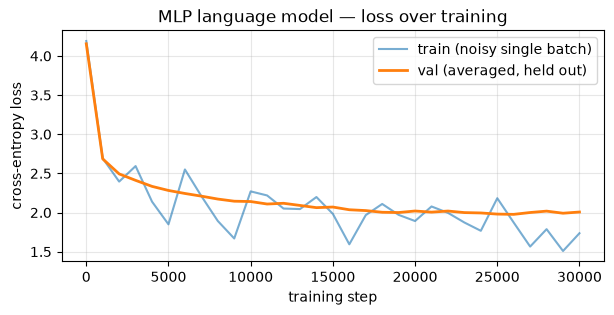

In [18]:
max_steps = 30000
batch_size = 64
train_hist, val_hist = [], []

@torch.no_grad()
def eval_val_loss(n_batches=40):
    # Average over many random validation batches for a stable held-out estimate
    losses = torch.zeros(n_batches)
    for i in range(n_batches):
        ix = torch.randint(len(Xva), (256,))
        losses[i] = F.cross_entropy(forward(Xva[ix]), Yva[ix]).item()
    return losses.mean().item()

for step in range(max_steps):
    ix = torch.randint(len(Xtr), (batch_size,))       # mini-batch: 64 random windows
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = forward(Xb)                              # 1. predict (forward pass)
    loss = F.cross_entropy(logits, Yb)                # 2. score

    for p in parameters:                              # (reset — grads accumulate, same as ever), parameters = [C, W1, b1, W2, b2]
        p.grad = None
    loss.backward()                                   # 3. assign blame (fills every p.grad)

    lr = 0.1 if step < max_steps // 2 else 0.01      # blunt decay: one drop halfway
    for p in parameters:
        p.data -= lr * p.grad                        # 4. nudge — the exact update from the neural-net notebook

    if step % 1000 == 0 or step == max_steps - 1:
        vl = eval_val_loss()
        train_hist.append((step, loss.item())); val_hist.append((step, vl))
        if step % 5000 == 0 or step == max_steps - 1:
            print(f'step {step:5d}:  batch loss {loss.item():.3f}   val loss {vl:.3f}')

plt.figure(figsize=(7, 3))
plt.plot(*zip(*train_hist), label='train (noisy single batch)', alpha=0.6)
plt.plot(*zip(*val_hist), label='val (averaged, held out)', linewidth=2)
plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
plt.title('MLP language model — loss over training'); plt.legend(); plt.grid(alpha=0.3)
plt.show()


### Where this lands

Read the final validation loss against the two reference points from the intro (same data, same character vocabulary):

| Model | Context it can use | Val loss |
|-------|--------------------|----------|
| Bigram — predicts from the current character alone | 1 character | ~2.49 |
| **MLP over embeddings (this notebook)** | **8 characters, fixed** | **~2.0** |
| Full GPT (built in the next notebook) | 32 characters, learned weighting | ~1.74 |

Beating the bigram was guaranteed — eight characters of context instead of one. The interesting part is the *gap to the GPT*, because it isn't mainly about parameter count. It's about what kind of function each model can be, and Step 9 pins down exactly what the MLP can't do. First, let's enjoy what it *can* do.


## Step 8: Sampling, and what the embeddings learned

### Generating text

Generation is a simple loop: predict a distribution for the next character, **sample** from it (`torch.multinomial` — draw weighted by probability, so a 0.4-chance character is picked 40% of the time), append the pick to the context, slide the window, repeat. Sampling rather than always taking the top character is what keeps the output varied instead of deterministic and loopy.

Expect mid-grade gibberish that is nonetheless *clearly* Shakespeare-shaped: real short words, plausible made-up longer ones, line breaks and `Speaker:` patterns in roughly the right places. That's what loss ≈ 2.0 looks like — far better than the letter-soup a bigram produces, still well short of a GPT.


In [9]:
@torch.no_grad()
def generate(n_chars, prompt='\n'):
    # Start from a prompt, left-padded with newlines to fill the 8-slot context window.
    context = encode('\n' * block_size + prompt)[-block_size:]
    out = []
    for _ in range(n_chars):
        logits = forward(torch.tensor([context]))     # (1, 65) scores for the next character
        probs = F.softmax(logits, dim=-1)             # now we genuinely need probabilities
        nxt = torch.multinomial(probs, num_samples=1).item()   # weighted random draw
        out.append(itos[nxt])
        context = context[1:] + [nxt]                 # slide the window: drop oldest, append pick
    return prompt + ''.join(out)

print(generate(400))



IIGAD KOS
MAY EMwixhall sertar loved intrer ue soneth to staygry:
If hax sweet maygerly and has niy shats, younor tou; 'tints stcours you
wherven in man thall the tueate, Bill?
Wich do sar
Mase slil astanghan, as, plice of my prayul I swon, I make bloond sid tood
sime worlins of Iut the my think,
Whas foue his apther'd nedver of all the swocls.
Lecom a'lr nopfaing, I it'e bran the railes
What rlak


### The geometry the table discovered

Time to cash the Step 4 promise: similar characters should have drifted toward each other in the embedding space. The table `C` is 10-dimensional, so to draw it we project onto the two directions of largest variation (**PCA**, computed with one SVD call — a projection for plotting only, nothing is retrained).

Nobody told the model about vowels, consonants, or case. Everything in this plot was inferred from which characters turn out to be *interchangeable* when predicting Shakespeare. Look for: the vowels bunching together, punctuation off on its own, uppercase (which behaves differently — it follows `\n` and speaker patterns) separated from lowercase, and the rare characters (`$`, `&`, `X`) floating wherever their few gradient updates happened to leave them.


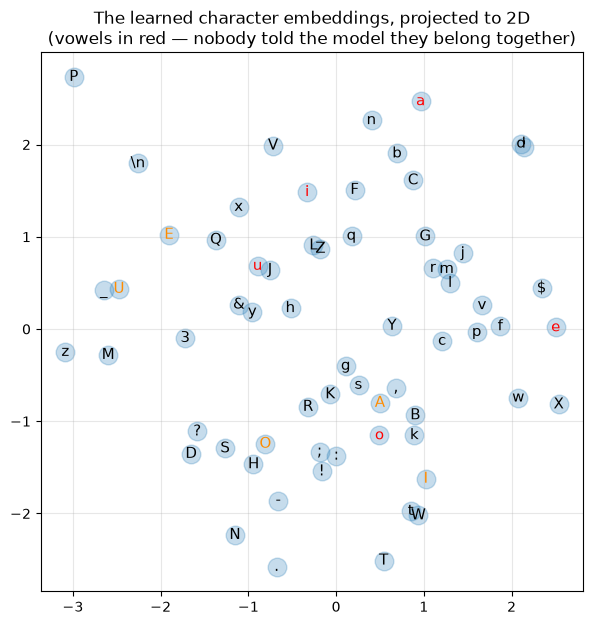

In [10]:
# Project the (65, 10) embedding table to 2D with PCA (SVD on the centered table) and label every character.
with torch.no_grad():
    Cc = C - C.mean(dim=0)
    U, S, V = torch.linalg.svd(Cc, full_matrices=False)
    P = Cc @ V[:2].T          # (65, 2): each character's position along the top-2 variance directions

plt.figure(figsize=(7, 7))
plt.scatter(P[:, 0], P[:, 1], s=180, alpha=0.25)
for i in range(vocab_size):
    label = itos[i] if itos[i] not in ('\n', ' ') else {'\n': '\\n', ' ': '_'}[itos[i]]
    color = 'red' if itos[i] in 'aeiou' else ('darkorange' if itos[i] in 'AEIOU' else 'black')
    plt.text(P[i, 0], P[i, 1], label, ha='center', va='center', fontsize=11, color=color)
plt.title('The learned character embeddings, projected to 2D\n(vowels in red — nobody told the model they belong together)')
plt.grid(alpha=0.3)
plt.show()


## Step 9: The wall — why this can't scale

The MLP works. So why did the field abandon this architecture for language? Try to grow the context from 8 to 32 characters (the full GPT's window), and three structural problems surface:

**1. No weight sharing across positions.** The concatenation in Step 5 gives *each window slot its own private slice of `W1`* — the weights that read position 1 never touch position 2. Everything the model learns about `q`-usually-precedes-`u` must be relearned separately for all 8 (or 32, or 1000) places `q` can sit in the window. The knowledge doesn't transfer along the sequence.

**2. Parameters grow with context length.** `W1` has shape `(context × n_embd, hidden)`. Context 8 → 80 input columns; context 32 → 320; context 1000 → 10,000. The first layer balloons linearly with how far back the model can look — you pay in parameters for every character of memory, whether or not it's useful.

**3. Every context position is weighted the same way regardless of content.** The flattened input treats slot 3 identically whether it holds a load-bearing `:` or filler whitespace. What we want is for the *model itself* to decide, per prediction, which earlier characters matter — weights that depend on the data, not on the slot.

Problem 3 is, almost word for word, the question the next notebook opens with: *"when predicting the next character, how much of the earlier text is the model allowed to use, and how well?"* Attention is the answer — a mechanism where each position computes, from the content, how much of every earlier position to blend in. One set of weights, shared across all positions (fixing 1 and 2), producing data-dependent mixing (fixing 3).

## Summary

What we built, and what it hands to the next notebook:

| Component | What it does |
|-----------|-------------|
| Tensors + autograd | The `Value` class, batched — verified identical on `(a+b)*b` |
| The windowed dataset | Text supervising itself: 8 characters → the 9th |
| Embedding table `C` | Learned lookup: character → vector; similarity in meaning becomes similarity in geometry |
| The MLP | Concatenated embeddings → hidden layer → 65 logits, all parameters hand-managed |
| Softmax + cross-entropy | The multi-class loss every language model in these notebooks trains on |

Two of these — the embedding table and the softmax/cross-entropy pair — pass through to every later notebook essentially unchanged; a GPT's first layer and final loss are exactly these, wider. The part that gets *replaced* is the middle: concatenation-plus-MLP gives way to attention, for the three reasons above.

### What we learned

- **PyTorch tensors run the same autograd we built by hand** — verified gradient-for-gradient on `(a + b) * b`. A tensor is `Value` wrapping an array, and one matmul replaces thousands of scalar operations.
- **Text supervises itself**: sliding a window over a corpus manufactures (context → next character) examples by the million, no labeling required.
- **Raw token IDs can't be fed to a network** — their magnitudes are arbitrary. One-hot fixes that but makes every token equidistant from every other, so nothing generalizes.
- **An embedding lookup is a linear layer in disguise**: `one_hot(i) @ W == W[i]`, with the 64 zero-multiplications skipped.
- **A token embedding table always has `vocab_size` rows** — IDs are row indices, so the table must cover largest ID + 1, one row per token. The number of *columns* (`n_embd`) is a free design choice.
- **Only rows that get looked up receive gradients** — rare tokens train rarely.
- **Similarity in meaning becomes similarity in geometry**, discovered by training, not programmed: the vowels clustered on their own.
- **`-log(1/vocab_size)` is the untrained-model loss** — a free sanity check at the start of every language-model training run (4.17 for 65 tokens).
- **A fixed-context MLP cannot scale**: each window slot owns private weights, parameters grow with context length, and slot weighting ignores content. Those three failures are the case for attention.

**Next:** the [transformer notebook](transformer.ipynb) rebuilds this same next-character predictor with attention in the middle, starting from a bigram baseline and adding one idea at a time. After that, the [tokenizer notebook](tokenizer.ipynb) replaces the character-level tokenizer both notebooks share with the real thing.


## Your turn: make it stick

Reading along is the comfortable half of learning. Before moving on, do these two things.

### 1. Summarize it yourself, then verify with an LLM

Close the notebook and write a summary from memory — a few sentences per question, no peeking:

- Why can't raw token IDs be fed into a network? Why is one-hot correct but a dead end?
- What is an embedding table? How many rows must it have, and what decides the number of columns?
- What's the relationship between `one_hot(i) @ W` and `W[i]`?
- What loss should an untrained model show, and why is that a useful number?
- What are the three reasons this MLP architecture can't scale its context window?

Then paste your summary into an LLM with a prompt like:

> *"I just studied embeddings and MLP language models (Bengio 2003 / makemore style). Here is my summary from memory: [your summary]. Check every claim for correctness, tell me what I've missed or muddled, then quiz me with three follow-up questions aimed at my weakest spot."*

### 2. Rebuild a small version

Build a **name generator** — same architecture, different data, small enough to see everything:

1. Get a plain-text list of first names (a few hundred is plenty; any language). Vocabulary: the letters plus a `.` end-of-name marker — around 27 tokens.
2. Build (context → next letter) windows with `block_size = 3`, train the same embedding → concatenate → tanh → logits MLP from Step 5, all parameters by hand.
3. Use `n_embd = 2` — deliberately, so you can scatter-plot the embedding table *directly*, no PCA needed.
4. Sample new names until they look plausible-but-not-memorized.

**Done when**: loss starts near `-log(1/27) ≈ 3.3` and falls well below it; the 2D embedding plot shows vowels clustered; sampled names are pronounceable and mostly *not* in your training list. Bonus: re-derive why the parameter count is what `sum(p.numel() ...)` prints.

> ➡ **Next in the series:** [Building a Transformer from Scratch](transformer.ipynb)
